# Modelo Causal v8 — Simulações Contrafactuais

**Objetivo 5 do TCC:** Realizar simulações contrafactuais para analisar o impacto de possíveis intervenções operacionais.

## Pergunta central
> *Se a operação reduzir a prevalência de um tratamento em X%, qual o impacto esperado nos outcomes de negócio?*

## ATEs utilizados (notebooks v6 e v7)

| Tratamento | Outcome | ATE | IC 95% | Fonte |
|---|---|---|---|---|
| `despacho_lento` | `entrega_atrasada` | +0.0791 | [0.073, 0.084] | v6 |
| `despacho_lento` | `review_positivo` | −0.0876 | [−0.095, −0.081] | v6 |
| `aprovacao_lenta` | `entrega_atrasada` | +0.0162 | [0.012, 0.021] | v6 |
| `aprovacao_lenta` | `review_positivo` | −0.0103 | [−0.017, −0.004] | v6 |
| `pedido_grande` | `entrega_atrasada` | −0.0156 | [−0.020, −0.010] | v7 |
| `pedido_grande` | `review_positivo` | −0.1678 | [−0.178, −0.157] | v7 |

## Lógica da simulação

Para cada nível de intervenção (redução de 0% a 100% do tratamento):

```
N_movidos = N_tratados × reducao
Mudanca_outcome = N_movidos × (−ATE)
```

Intuição: mover alguém de T=1 para T=0 muda o outcome esperado em −ATE.

## 1. Imports e dados

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from app.config.settings import INTERIM_DATA_DIR

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, "interim_dataset.parquet"))

date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["approval_time_hours"] = (
    df["order_approved_at"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

df["dispatch_time_days"] = (
    df["order_delivered_carrier_date"] - df["order_approved_at"]
).dt.days

df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

df["perc_freight"] = df["total_freight"] / df["total_price"]

df["despacho_lento"]   = (df["dispatch_time_days"] > 3).astype(int)
df["aprovacao_lenta"]  = (df["approval_time_hours"] > 24).astype(int)
df["pedido_grande"]    = (df["n_items"] > 1).astype(int)
df["entrega_atrasada"] = (df["delay_days"] > 0).astype(int)
df["review_positivo"]  = (df["review_score"] >= 4).astype(int)

N_TOTAL = len(df)
print(f"Total de pedidos: {N_TOTAL:,}")

Total de pedidos: 97,712


## 2. Cenário base — situação atual

In [3]:
tratamentos = ["despacho_lento", "aprovacao_lenta", "pedido_grande"]
outcomes    = ["entrega_atrasada", "review_positivo"]

print("=" * 55)
print("CENÁRIO BASE — situação atual")
print("=" * 55)

print("\nTratamentos:")
for t in tratamentos:
    n = df[t].sum()
    p = df[t].mean()
    print(f"  {t:<22}: {n:>7,} pedidos ({p*100:.1f}%)")

print("\nOutcomes:")
for o in outcomes:
    n = df[o].sum()
    p = df[o].mean()
    print(f"  {o:<22}: {n:>7,} pedidos ({p*100:.1f}%)")

CENÁRIO BASE — situação atual

Tratamentos:
  despacho_lento        :  20,262 pedidos (20.7%)
  aprovacao_lenta       :  17,103 pedidos (17.5%)
  pedido_grande         :   9,677 pedidos (9.9%)

Outcomes:
  entrega_atrasada      :   6,535 pedidos (6.7%)
  review_positivo       :  75,790 pedidos (77.6%)


## 3. ATEs e ICs dos modelos anteriores

In [4]:
# ATEs confiáveis dos notebooks v6 e v7
ATES = [
    {"treatment": "despacho_lento",  "outcome": "entrega_atrasada",
     "ate": +0.0791, "ic_lower": +0.0734, "ic_upper": +0.0838, "fonte": "v6"},

    {"treatment": "despacho_lento",  "outcome": "review_positivo",
     "ate": -0.0876, "ic_lower": -0.0949, "ic_upper": -0.0807, "fonte": "v6"},

    {"treatment": "aprovacao_lenta", "outcome": "entrega_atrasada",
     "ate": +0.0162, "ic_lower": +0.0122, "ic_upper": +0.0208, "fonte": "v6"},

    {"treatment": "aprovacao_lenta", "outcome": "review_positivo",
     "ate": -0.0103, "ic_lower": -0.0172, "ic_upper": -0.0035, "fonte": "v6"},

    {"treatment": "pedido_grande",   "outcome": "entrega_atrasada",
     "ate": -0.0156, "ic_lower": -0.0205, "ic_upper": -0.0102, "fonte": "v7"},

    {"treatment": "pedido_grande",   "outcome": "review_positivo",
     "ate": -0.1678, "ic_lower": -0.1783, "ic_upper": -0.1567, "fonte": "v7"},
]

df_ates = pd.DataFrame(ATES)
print(df_ates[["treatment", "outcome", "ate", "ic_lower", "ic_upper", "fonte"]].to_string(index=False))

      treatment          outcome     ate  ic_lower  ic_upper fonte
 despacho_lento entrega_atrasada  0.0791    0.0734    0.0838    v6
 despacho_lento  review_positivo -0.0876   -0.0949   -0.0807    v6
aprovacao_lenta entrega_atrasada  0.0162    0.0122    0.0208    v6
aprovacao_lenta  review_positivo -0.0103   -0.0172   -0.0035    v6
  pedido_grande entrega_atrasada -0.0156   -0.0205   -0.0102    v7
  pedido_grande  review_positivo -0.1678   -0.1783   -0.1567    v7


## 4. Função de simulação contrafactual

In [5]:
def simular_contrafactual(df, treatment, outcome, ate, ic_lower, ic_upper,
                           niveis=[0.0, 0.25, 0.50, 0.75, 1.0]):
    """
    Simula o impacto de reduzir a prevalência do tratamento.

    Para cada nível de redução:
      N_movidos = N_tratados × reducao
      Mudança no outcome = N_movidos × (−ATE)
        - ATE positivo: reduzir tratamento MELHORA o outcome (menos atrasos)
        - ATE negativo: reduzir tratamento PIORA o outcome (menos reviews positivos)
    """
    n_tratados      = int(df[treatment].sum())
    n_outcome_atual = int(df[outcome].sum())
    prev_tratamento = df[treatment].mean()
    prev_outcome    = df[outcome].mean()

    rows = []
    for reducao in niveis:
        n_movidos     = n_tratados * reducao
        delta_ate     = n_movidos * (-ate)
        delta_lower   = n_movidos * (-ic_upper)   # IC invertido
        delta_upper   = n_movidos * (-ic_lower)

        n_outcome_cf  = n_outcome_atual + delta_ate
        prev_cf       = n_outcome_cf / len(df)

        rows.append({
            "Reducao (%)": f"{reducao*100:.0f}%",
            "N movidos":   int(n_movidos),
            "Delta outcome (ATE)": int(delta_ate),
            "IC inf delta": int(delta_lower),
            "IC sup delta": int(delta_upper),
            "N outcome CF": int(n_outcome_cf),
            "Prev. CF (%)": f"{prev_cf*100:.2f}%",
            "Var. relativa (%)": f"{(delta_ate/n_outcome_atual)*100:+.1f}%"
        })

    return pd.DataFrame(rows), n_tratados, n_outcome_atual

## 5. Simulações por tratamento

### 5.1 — Despacho lento

In [6]:
print("=" * 65)
print("INTERVENÇÃO: reduzir despacho lento (>3 dias)")
print("=" * 65)

for r in [a for a in ATES if a["treatment"] == "despacho_lento"]:
    df_cf, n_t, n_o = simular_contrafactual(
        df, r["treatment"], r["outcome"],
        r["ate"], r["ic_lower"], r["ic_upper"]
    )
    print(f"\nOutcome: {r['outcome']}")
    print(f"  Pedidos com despacho lento: {n_t:,} ({n_t/N_TOTAL*100:.1f}%)")
    print(f"  {r['outcome']} atual: {n_o:,} ({n_o/N_TOTAL*100:.1f}%)")
    print(df_cf.to_string(index=False))

INTERVENÇÃO: reduzir despacho lento (>3 dias)

Outcome: entrega_atrasada
  Pedidos com despacho lento: 20,262 (20.7%)
  entrega_atrasada atual: 6,535 (6.7%)
Reducao (%)  N movidos  Delta outcome (ATE)  IC inf delta  IC sup delta  N outcome CF Prev. CF (%) Var. relativa (%)
         0%          0                    0             0             0          6535        6.69%             -0.0%
        25%       5065                 -400          -424          -371          6134        6.28%             -6.1%
        50%      10131                 -801          -848          -743          5733        5.87%            -12.3%
        75%      15196                -1202         -1273         -1115          5332        5.46%            -18.4%
       100%      20262                -1602         -1697         -1487          4932        5.05%            -24.5%

Outcome: review_positivo
  Pedidos com despacho lento: 20,262 (20.7%)
  review_positivo atual: 75,790 (77.6%)
Reducao (%)  N movidos  Delta 

### 5.2 — Aprovação lenta

In [7]:
print("=" * 65)
print("INTERVENÇÃO: reduzir aprovação lenta (>24h)")
print("=" * 65)

for r in [a for a in ATES if a["treatment"] == "aprovacao_lenta"]:
    df_cf, n_t, n_o = simular_contrafactual(
        df, r["treatment"], r["outcome"],
        r["ate"], r["ic_lower"], r["ic_upper"]
    )
    print(f"\nOutcome: {r['outcome']}")
    print(f"  Pedidos com aprovação lenta: {n_t:,} ({n_t/N_TOTAL*100:.1f}%)")
    print(f"  {r['outcome']} atual: {n_o:,} ({n_o/N_TOTAL*100:.1f}%)")
    print(df_cf.to_string(index=False))

INTERVENÇÃO: reduzir aprovação lenta (>24h)

Outcome: entrega_atrasada
  Pedidos com aprovação lenta: 17,103 (17.5%)
  entrega_atrasada atual: 6,535 (6.7%)
Reducao (%)  N movidos  Delta outcome (ATE)  IC inf delta  IC sup delta  N outcome CF Prev. CF (%) Var. relativa (%)
         0%          0                    0             0             0          6535        6.69%             -0.0%
        25%       4275                  -69           -88           -52          6465        6.62%             -1.1%
        50%       8551                 -138          -177          -104          6396        6.55%             -2.1%
        75%      12827                 -207          -266          -156          6327        6.48%             -3.2%
       100%      17103                 -277          -355          -208          6257        6.40%             -4.2%

Outcome: review_positivo
  Pedidos com aprovação lenta: 17,103 (17.5%)
  review_positivo atual: 75,790 (77.6%)
Reducao (%)  N movidos  Delta 

### 5.3 — Pedido grande

In [8]:
print("=" * 65)
print("INTERVENÇÃO: reduzir pedidos grandes (>1 item)")
print("=" * 65)

for r in [a for a in ATES if a["treatment"] == "pedido_grande"]:
    df_cf, n_t, n_o = simular_contrafactual(
        df, r["treatment"], r["outcome"],
        r["ate"], r["ic_lower"], r["ic_upper"]
    )
    print(f"\nOutcome: {r['outcome']}")
    print(f"  Pedidos grandes: {n_t:,} ({n_t/N_TOTAL*100:.1f}%)")
    print(f"  {r['outcome']} atual: {n_o:,} ({n_o/N_TOTAL*100:.1f}%)")
    print(df_cf.to_string(index=False))

INTERVENÇÃO: reduzir pedidos grandes (>1 item)

Outcome: entrega_atrasada
  Pedidos grandes: 9,677 (9.9%)
  entrega_atrasada atual: 6,535 (6.7%)
Reducao (%)  N movidos  Delta outcome (ATE)  IC inf delta  IC sup delta  N outcome CF Prev. CF (%) Var. relativa (%)
         0%          0                    0             0             0          6535        6.69%             +0.0%
        25%       2419                   37            24            49          6572        6.73%             +0.6%
        50%       4838                   75            49            99          6610        6.77%             +1.2%
        75%       7257                  113            74           148          6648        6.80%             +1.7%
       100%       9677                  150            98           198          6685        6.84%             +2.3%

Outcome: review_positivo
  Pedidos grandes: 9,677 (9.9%)
  review_positivo atual: 75,790 (77.6%)
Reducao (%)  N movidos  Delta outcome (ATE)  IC inf del

## 6. Curvas de intervenção

Visualiza o impacto no outcome para cada nível de redução do tratamento.

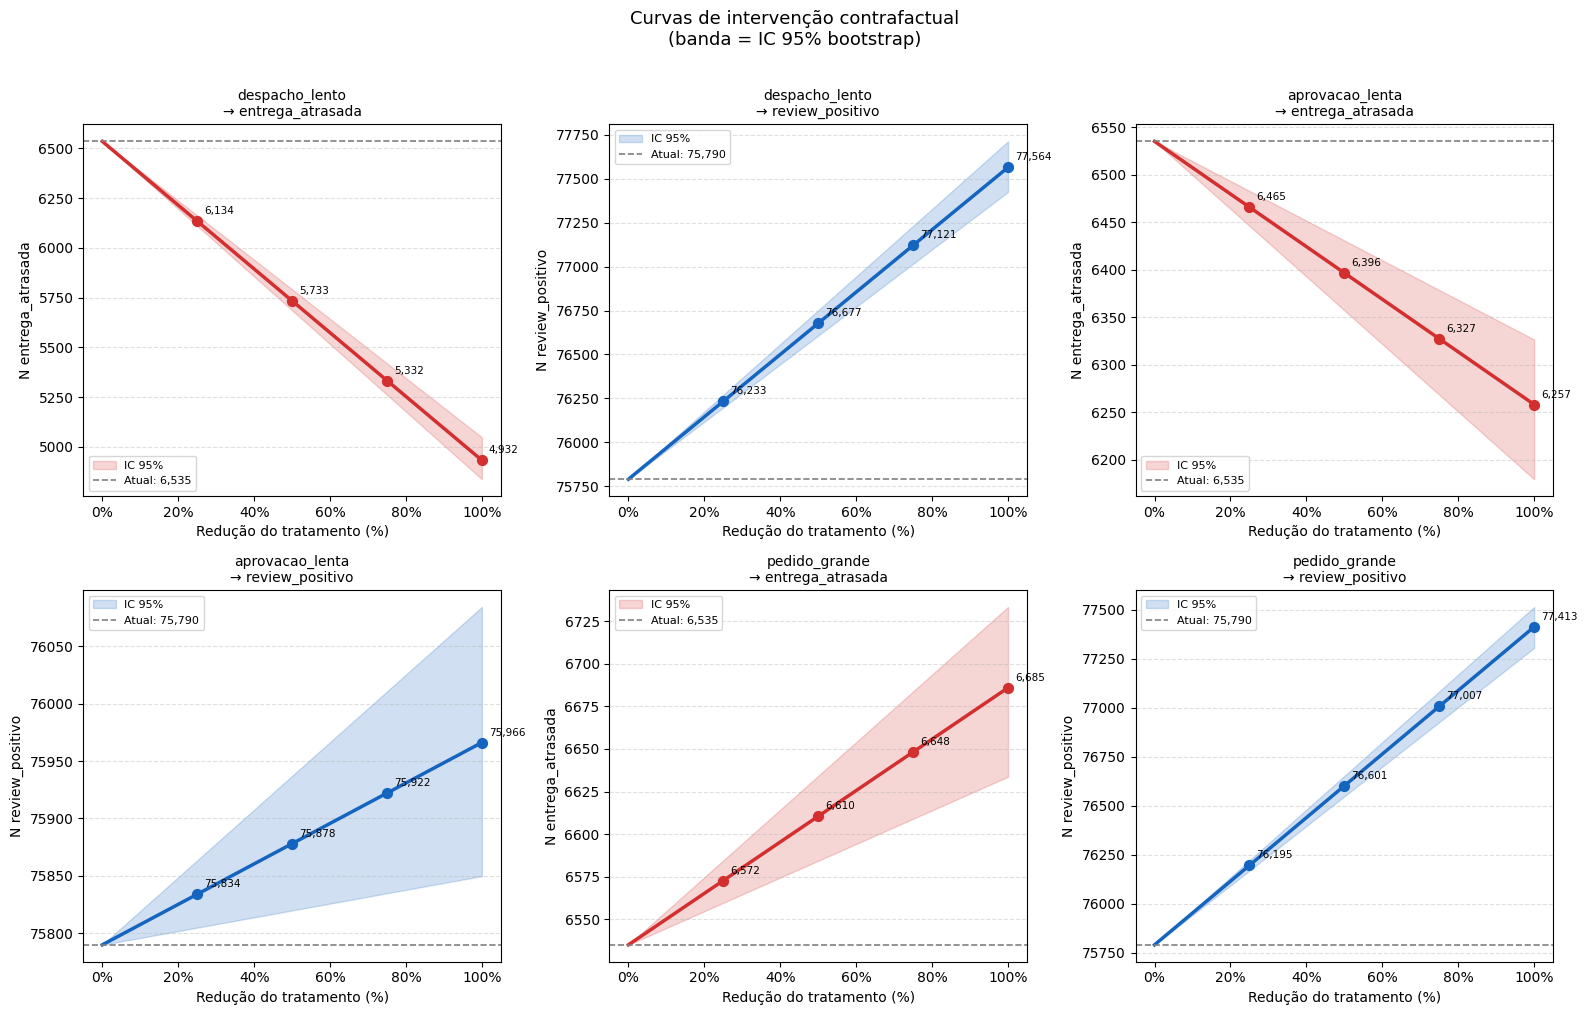

In [9]:
niveis_cont = np.linspace(0, 1, 101)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cores_outcome = {"entrega_atrasada": "#d32f2f", "review_positivo": "#1565c0"}

for i, r in enumerate(ATES):
    n_tratados      = int(df[r["treatment"]].sum())
    n_outcome_atual = int(df[r["outcome"]].sum())

    deltas      = [n_tratados * nivel * (-r["ate"])       for nivel in niveis_cont]
    deltas_low  = [n_tratados * nivel * (-r["ic_upper"])  for nivel in niveis_cont]
    deltas_high = [n_tratados * nivel * (-r["ic_lower"])  for nivel in niveis_cont]

    n_cfs      = [n_outcome_atual + d for d in deltas]
    n_cfs_low  = [n_outcome_atual + d for d in deltas_low]
    n_cfs_high = [n_outcome_atual + d for d in deltas_high]

    cor = cores_outcome[r["outcome"]]
    ax  = axes[i]

    ax.plot(niveis_cont * 100, n_cfs, color=cor, linewidth=2.5)
    ax.fill_between(niveis_cont * 100, n_cfs_low, n_cfs_high,
                    alpha=0.2, color=cor, label="IC 95%")
    ax.axhline(n_outcome_atual, color="gray", linestyle="--",
               linewidth=1.2, label=f"Atual: {n_outcome_atual:,}")

    # Marca os pontos 25%, 50%, 75%, 100%
    for pct in [25, 50, 75, 100]:
        idx   = pct
        y_val = n_cfs[idx]
        ax.scatter(pct, y_val, color=cor, zorder=5, s=50)
        ax.annotate(f"{int(y_val):,}", (pct, y_val),
                    textcoords="offset points", xytext=(5, 5), fontsize=7.5)

    ax.set_title(f"{r['treatment']}\n→ {r['outcome']}", fontsize=10)
    ax.set_xlabel("Redução do tratamento (%)")
    ax.set_ylabel(f"N {r['outcome']}")
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

plt.suptitle("Curvas de intervenção contrafactual\n"
             "(banda = IC 95% bootstrap)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../../reports/figures/contrafactual_curvas.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Intervenção combinada — despacho + aprovação

Simula o impacto de agir nos dois gargalos operacionais ao mesmo tempo.

In [10]:
n_atrasada_atual  = int(df["entrega_atrasada"].sum())
n_review_atual    = int(df["review_positivo"].sum())

n_despacho  = int(df["despacho_lento"].sum())
n_aprovacao = int(df["aprovacao_lenta"].sum())

ate_desp_atr  = +0.0791
ate_apro_atr  = +0.0162
ate_desp_rev  = -0.0876
ate_apro_rev  = -0.0103

print("=" * 65)
print("INTERVENÇÃO COMBINADA: despacho lento + aprovação lenta")
print("=" * 65)
print(f"{'Redução':<10} {'Atrasos evitados':>18} {'Reviews ganhos':>16} "
      f"{'Atrasos CF':>12} {'Reviews CF':>12}")
print("-" * 70)

for reducao in [0.25, 0.50, 0.75, 1.0]:
    delta_atr = (n_despacho * reducao * (-ate_desp_atr) +
                 n_aprovacao * reducao * (-ate_apro_atr))
    delta_rev = (n_despacho * reducao * (-ate_desp_rev) +
                 n_aprovacao * reducao * (-ate_apro_rev))

    n_atr_cf = n_atrasada_atual + delta_atr
    n_rev_cf = n_review_atual   + delta_rev

    print(f"{reducao*100:>6.0f}%   "
          f"{int(delta_atr):>+16,}   "
          f"{int(delta_rev):>+14,}   "
          f"{int(n_atr_cf):>10,}   "
          f"{int(n_rev_cf):>10,}")

INTERVENÇÃO COMBINADA: despacho lento + aprovação lenta
Redução      Atrasos evitados   Reviews ganhos   Atrasos CF   Reviews CF
----------------------------------------------------------------------
    25%               -469             +487        6,065       76,277
    50%               -939             +975        5,595       76,765
    75%             -1,409           +1,463        5,125       77,253
   100%             -1,879           +1,951        4,655       77,741


## 8. Resumo executivo — impacto de reduzir 50% cada tratamento

In [11]:
REDUCAO = 0.50
rows = []

for r in ATES:
    n_t   = int(df[r["treatment"]].sum())
    n_o   = int(df[r["outcome"]].sum())
    n_mov = int(n_t * REDUCAO)
    delta = int(n_mov * (-r["ate"]))
    delta_low  = int(n_mov * (-r["ic_upper"]))
    delta_high = int(n_mov * (-r["ic_lower"]))
    var_rel = (delta / n_o) * 100

    direcao = "melhora" if delta > 0 and r["outcome"] == "entrega_atrasada" else \
              "melhora" if delta < 0 and r["outcome"] == "entrega_atrasada" else \
              "melhora" if delta > 0 and r["outcome"] == "review_positivo" else "piora"

    rows.append({
        "Intervenção": f"{r['treatment']} −50%",
        "Outcome":     r["outcome"],
        "N movidos":   f"{n_mov:,}",
        "Impacto": f"{delta:+,} [{delta_low:+,}, {delta_high:+,}]",
        "Var. relativa": f"{var_rel:+.1f}%",
        "Direção": direcao
    })

df_resumo = pd.DataFrame(rows)
print("RESUMO: Impacto estimado de reduzir cada tratamento em 50%")
print("=" * 80)
print(df_resumo.to_string(index=False))

RESUMO: Impacto estimado de reduzir cada tratamento em 50%
         Intervenção          Outcome N movidos           Impacto Var. relativa Direção
 despacho_lento −50% entrega_atrasada    10,131 -801 [-848, -743]        -12.3% melhora
 despacho_lento −50%  review_positivo    10,131 +887 [+817, +961]         +1.2% melhora
aprovacao_lenta −50% entrega_atrasada     8,551 -138 [-177, -104]         -2.1% melhora
aprovacao_lenta −50%  review_positivo     8,551   +88 [+29, +147]         +0.1% melhora
  pedido_grande −50% entrega_atrasada     4,838    +75 [+49, +99]         +1.1% melhora
  pedido_grande −50%  review_positivo     4,838 +811 [+758, +862]         +1.1% melhora


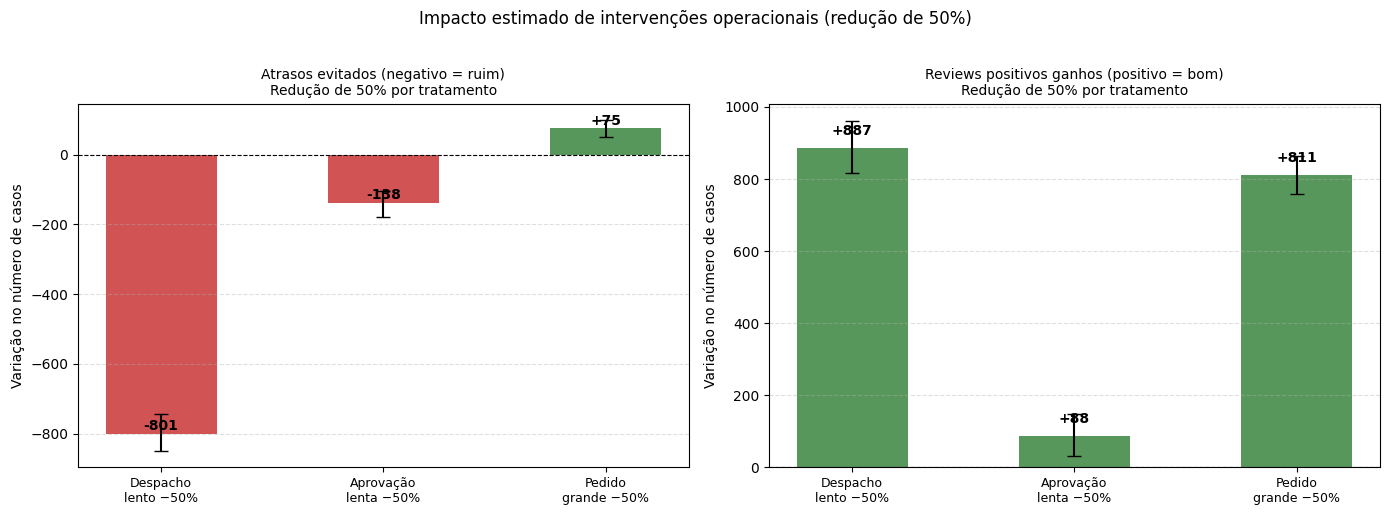

In [12]:
# Gráfico resumo — impacto de redução de 50%
tratamentos_plot = ["despacho_lento", "aprovacao_lenta", "pedido_grande"]
labels_t = ["Despacho\nlento −50%", "Aprovação\nlenta −50%", "Pedido\ngrande −50%"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, outcome in enumerate(["entrega_atrasada", "review_positivo"]):
    deltas, errs_low, errs_high, cores = [], [], [], []

    for t in tratamentos_plot:
        r = next(x for x in ATES if x["treatment"] == t and x["outcome"] == outcome)
        n_t   = int(df[t].sum())
        n_mov = int(n_t * 0.5)
        delta      = n_mov * (-r["ate"])
        delta_low  = n_mov * (-r["ic_upper"])
        delta_high = n_mov * (-r["ic_lower"])
        deltas.append(delta)
        errs_low.append(delta - delta_low)
        errs_high.append(delta_high - delta)
        cores.append("#2e7d32" if delta > 0 else "#c62828")

    x = np.arange(len(tratamentos_plot))
    bars = axes[ax_idx].bar(x, deltas, color=cores, alpha=0.8, width=0.5)
    axes[ax_idx].errorbar(x, deltas, yerr=[errs_low, errs_high],
                          fmt="none", color="black", capsize=5, linewidth=1.5)
    axes[ax_idx].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(labels_t, fontsize=9)
    axes[ax_idx].set_ylabel("Variação no número de casos")
    titulo = ("Atrasos evitados (negativo = ruim)"
              if outcome == "entrega_atrasada"
              else "Reviews positivos ganhos (positivo = bom)")
    axes[ax_idx].set_title(f"{titulo}\nRedução de 50% por tratamento", fontsize=10)
    axes[ax_idx].grid(axis="y", linestyle="--", alpha=0.4)

    for bar, val in zip(bars, deltas):
        axes[ax_idx].text(
            bar.get_x() + bar.get_width() / 2,
            val + (max(deltas) * 0.03),
            f"{int(val):+,}", ha="center", va="bottom", fontsize=10, fontweight="bold"
        )

plt.suptitle("Impacto estimado de intervenções operacionais (redução de 50%)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../../reports/figures/contrafactual_resumo_50pct.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Interpretação FINAL 

- Com base nas simulações contrafactuais, uma redução de **50%** na prevalência de cada tratamento produziria os seguintes impactos estimados:

Base: **97.712 pedidos** | Período analisado: dataset Olist completo

---

### Cenário base (situação atual)

| Variável | N | Prevalência |
|---|---|---|
| Pedidos com despacho lento (>3 dias) | 20.262 | 20,7% |
| Pedidos com aprovação lenta (>24h) | 17.103 | 17,5% |
| Pedidos grandes (>1 item) | 9.677 | 9,9% |
| Entregas atrasadas | 6.535 | 6,7% |
| Reviews positivos (≥4 estrelas) | 75.790 | 77,6% |

---

### Impacto simulado — redução de 50% por tratamento

#### Despacho lento — maior alavanca operacional
- **Entrega atrasada**: −801 atrasos (−12,3%) → de 6.535 para **5.733**
- **Review positivo**: +887 avaliações positivas (+1,2%) → de 75.790 para **76.677**
- IC 95% atrasos: [−848, −743] | IC 95% reviews: [+817, +961]

#### Aprovação lenta — alavanca moderada
- **Entrega atrasada**: −138 atrasos (−2,1%) → de 6.535 para **6.396**
- **Review positivo**: +88 avaliações positivas (+0,1%) → de 75.790 para **75.878**
- IC 95% atrasos: [−177, −104] | IC 95% reviews: [+29, +147]

#### Pedido grande — efeito paradoxal
- **Entrega atrasada**: +75 atrasos (+1,2%) — pedidos grandes têm efeito protetor no atraso; reduzir sua prevalência **aumenta** levemente os atrasos
- **Review positivo**: +811 avaliações positivas (+1,1%) → de 75.790 para **76.601** — pedidos grandes reduzem satisfação; reduzir sua prevalência **melhora** os reviews

---

### Intervenção combinada — despacho + aprovação simultâneos

| Redução | Atrasos evitados | Reviews ganhos | Atrasos CF | Reviews CF |
|---|---|---|---|---|
| 25% | −469 | +487 | 6.065 | 76.277 |
| **50%** | **−939** | **+975** | **5.595** | **76.765** |
| 75% | −1.409 | +1.463 | 5.125 | 77.253 |
| 100% | −1.879 | +1.951 | 4.655 | 77.741 |

---

### Conclusão operacional

O **despacho lento** é a principal alavanca operacional: concentra o maior efeito causal tanto em atrasos quanto em satisfação do cliente. Reduzir o tempo de despacho de 3+ dias para ≤3 dias em metade dos casos afetados evitaria cerca de **800 atrasos** e geraria cerca de **880 reviews positivos adicionais** no período analisado.

> O **despacho lento** é a principal alavanca operacional identificada: responde por ~85% do impacto combinado nas entregas atrasadas e ~91% no ganho de reviews positivos.
>
> Uma intervenção focada em reduzir o tempo de despacho para ≤3 dias em **50% dos casos afetados** evitaria cerca de **801 atrasos** (−12,3%) e geraria cerca de **887 reviews positivos adicionais** (+1,2%) no período analisado.
>
> Agindo simultaneamente nos dois gargalos operacionais — despacho e aprovação — a redução de 50% evitaria **939 atrasos** e geraria **975 reviews positivos**, representando uma melhoria de **−14,4% nas entregas atrasadas** e **+1,3% na taxa de satisfação**.